In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/archive (3)')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
import os

for root, dirs, files in os.walk('/content/archive (3)'):
    print(root)
    print("Folders:", dirs[:5])
    break

/content/archive (3)
Folders: ['Tobacco 800 Dataset']


In [5]:
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision.models import vgg16

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [8]:
dataset = datasets.ImageFolder(
    root='/content/archive (3)',
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Tobacco 800 Dataset']
Total Images: 1290


In [9]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

902
193
195


In [10]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = vgg16(weights="IMAGENET1K_V1")

num_classes = len(dataset.classes)

model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    num_classes
)

model = model.to(device)

print("Model Loaded")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.1MB/s]


Model Loaded


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [13]:
def train_epoch():

    model.train()

    correct = 0
    total = 0
    loss_sum = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        loss_sum += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    return loss_sum/len(train_loader), acc

In [14]:
def validate():

    model.eval()

    correct = 0
    total = 0
    loss_sum = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss_sum += loss.item()

            _, preds = torch.max(outputs,1)

            total += labels.size(0)

            correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    return loss_sum/len(val_loader), acc

In [26]:
EPOCHS = 1

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch()

    val_loss, val_acc = validate()

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Train Acc: {train_acc:.2f}%"
        f" | Val Acc: {val_acc:.2f}%"
    )

Epoch 1/1 | Train Acc: 100.00% | Val Acc: 100.00%


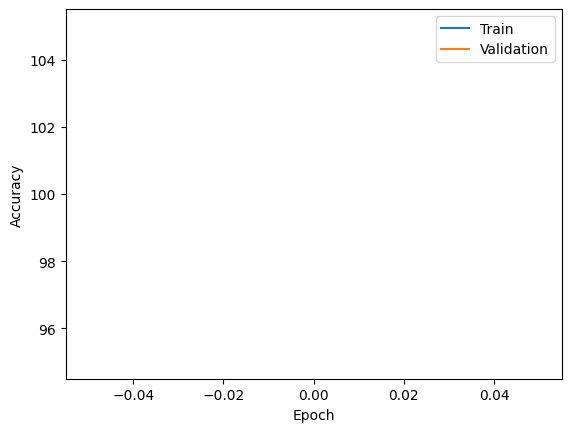

In [27]:
plt.plot(train_accs,label='Train')
plt.plot(val_accs,label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

In [28]:
model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        total += labels.size(0)

        correct += (preds.cpu() == labels).sum().item()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

test_acc = 100 * correct / total

print("Test Accuracy:", test_acc)

Test Accuracy: 100.0


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=dataset.classes
    )
)

                     precision    recall  f1-score   support

Tobacco 800 Dataset       1.00      1.00      1.00       195

           accuracy                           1.00       195
          macro avg       1.00      1.00      1.00       195
       weighted avg       1.00      1.00      1.00       195



In [30]:
feature_extractor = model.features

feature_extractor.eval()

sample_images, _ = next(iter(test_loader))

sample_images = sample_images.to(device)

with torch.no_grad():

    features = feature_extractor(sample_images)

print("Feature Shape:", features.shape)

Feature Shape: torch.Size([16, 512, 7, 7])
